# **PROYECTO ITLA EN CIFRAS**

# **1- Comprensión del Negocio**
---

## **Resumen del Proyecto y Metodología:**

El objetivo de este proyecto es construir y evaluar un sistema de aprendizaje automático capaz de predecir el número de estudiantes inscritos (desglosados por género) para el cuatrimestre Septiembre-Diciembre 2025 en 16 carreras tecnológicas del ITLA y el cuatrimestre Enero-Abril 2026.

**1- Objetivos específicos:**

- Hacer análisis descriptivo.

- Hacer análisis predictivo Septiembre-Diciembre 2025, y compararlo con el real.

- Hacer predicciones de Enero-Abril 2026.

- Utilizar todos los datos a excepción de los de Septiembre-Diciembre 2025 y realizar la predicción con el modelo mas adecuado de los entrenados (Gradient Boosting y Ramdon Forest).

- Análisis de Resultados: Modelos Predictivos de Inscripción Estudiantil (ITLA 2025)

**2- La metodología fue la siguiente:**

Basado en la metodología CRISP-DM (Cross-Industry Standard Process for Data Mining):

1. **Compresión del negocio**

En esta sección es en donde se analizan los objetivos y finalidad del proyecto, a la vez cómo se realizará el mismo y de qué manera.

2. **Compresión de los datos**

En esta sección cargaremos los datos y los analizaremos para entender cómo son los datos con los que estaremos trabajando, analizando su forma y variables clave.

3. **Preparación de los Datos**

En esta sección se preparan los datos, para ser utilizados, realizando desde limpieza de los mismos hasta transformaciones.

4. **Modelado**

En esta sección definimos los modelos a utilizar y realizamos el entrenamiento de los mismos.

5. **Evaluación**

En esta sección evaluamos los resultados de nuestros modelos utilizando distintas métricas de rendimiento.

6. **Despliegue**

En esta sección última, realizamos la tarea objetiva de la creación de dicho modelo, en este caso en específico implementándolo para la predicción del cuatrimestre Septiembre-Diciembre 2025 y el cuatrimestre Enero-Abril 2026.

# **2- Comprensión de los Datos**
---



## Importar Librerias

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

## Cargar Dataset

In [ ]:
#Importamos el Excel
df = pd.read_excel('Estadisticas-Inscritos-Educacion-Superior-2006-2025.xlsx')

df.head()

,Carrera,Estudiantes femeninos,Estudiantes masculinos,Cuatrimestre,Año
0,Tecnólogo en Desarrollo de Software,3,6,Septiembre- Diciembre,2006
1,Tecnólogo en Multimedia,8,9,Septiembre- Diciembre,2006
2,Tecnólogo en Redes de Información,13,19,Septiembre- Diciembre,2006
3,Tecnólogo en Manufactura Automatizada,8,5,Septiembre- Diciembre,2006
4,Tecnólogo en Desarrollo de Software,8,13,Enero - Abril,2007


## Comprensión del ITLA

### Carreras

In [ ]:
print(f"En el año 2006 el ITLA contaba con {df[df['Año'] == 2006]["Carrera"].nunique()} carreras, las cuales son:\n")
for i in list(df[df['Año'] == 2006]['Carrera']):
  print(i)

En el año 2006 el ITLA contaba con 4 carreras, las cuales son:

Tecnólogo en Desarrollo de Software
Tecnólogo en Multimedia
Tecnólogo en Redes de Información
Tecnólogo en Manufactura Automatizada


In [ ]:
print(f"Actualmente el ITLA cuenta con {df["Carrera"].nunique()} carreras las cuales son:\n")
for i in list(df[df['Año'] == 2025]['Carrera'].unique()):
  print(i)

Actualmente el ITLA cuenta con 20 carreras las cuales son:

Tecnólogo en Analítica y Ciencia de los Datos
Tecnólogo en Desarrollo de Simulaciones Interactivas y Videojuegos
Tecnólogo en Desarrollo de Software
Tecnólogo en Diseño Industrial
Tecnólogo en Energías Renovables
Tecnólogo en Informática Forense
Tecnólogo en Inteligencia Artificial
Tecnólogo en Manufactura Automatizada
Tecnólogo en Manufactura de Dispositivos Médicos 
Tecnólogo en Mecatrónica
Tecnólogo en Multimedia 
Tecnólogo en Redes de la Información
Tecnólogo en Seguridad Informática
Tecnólogo en Sonido
Tecnólogo en Telecomunicaciones
Tecnólogo en Ciberseguridad


### Cuatrimestres

In [ ]:
print("El ITLA Cuenta con los siguientes 3 periodos de cuatro meses, al año:")
df['Cuatrimestre'].value_counts()

El ITLA Cuenta con los siguientes 3 periodos de cuatro meses, al año:


,count
Cuatrimestre,
Septiembre- Diciembre,164
Mayo - Agosto,157
Enero - Abril,154


## Estructura del dataset

In [ ]:
# Ver las dimensiones del conjunto de datos
print("Dimensiones del conjunto de datos (filas y columnas):", df.shape)

# Ver las primeras filas del conjunto de datos
print("Primeras filas del conjunto de datos:")
display(df.head())

# Vemos las distintas características presentes en el dataset
print("\nCaracterísticas:")
display(pd.DataFrame(df.columns.tolist(),columns=['Características']))

Dimensiones del conjunto de datos (filas y columnas): (475, 5)
Primeras filas del conjunto de datos:


,Carrera,Estudiantes femeninos,Estudiantes masculinos,Cuatrimestre,Año
0,Tecnólogo en Desarrollo de Software,3,6,Septiembre- Diciembre,2006
1,Tecnólogo en Multimedia,8,9,Septiembre- Diciembre,2006
2,Tecnólogo en Redes de Información,13,19,Septiembre- Diciembre,2006
3,Tecnólogo en Manufactura Automatizada,8,5,Septiembre- Diciembre,2006
4,Tecnólogo en Desarrollo de Software,8,13,Enero - Abril,2007



Características:


,Características
0,Carrera
1,Estudiantes femeninos
2,Estudiantes masculinos
3,Cuatrimestre
4,Año


## Datos del dataset

### Resumen estadístico

In [ ]:
print("Descripcion estadistica del Dataset")
display(df.describe())
print("\n")

Descripcion estadistica del Dataset


,Estudiantes femeninos,Estudiantes masculinos,Año
count,475.000000,475.000000,475.000000
mean,63.048421,227.018947,2018.408421
std,91.339815,343.995654,5.467735
min,0.000000,2.000000,2006.000000
25%,10.000000,42.000000,2014.000000
50%,30.000000,117.000000,2020.000000
75%,72.000000,240.000000,2023.000000
max,712.000000,2038.000000,2025.000000


### Información de tipos de datos

In [ ]:
print("Informacion del Dataset")
display(df.info())
print("\n")

print("Tipos de datos")
display(df.dtypes)
print("\n")

Informacion del Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 475 entries, 0 to 474
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Carrera                 475 non-null    object
 1   Estudiantes femeninos   475 non-null    int64 
 2   Estudiantes masculinos  475 non-null    int64 
 3   Cuatrimestre            475 non-null    object
 4   Año                     475 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 18.7+ KB


None



Tipos de datos


,0
Carrera,object
Estudiantes femeninos,int64
Estudiantes masculinos,int64
Cuatrimestre,object
Año,int64


### Estudiantes Admitidos

#### Inscritos por año

<Figure size 640x480 with 0 Axes>

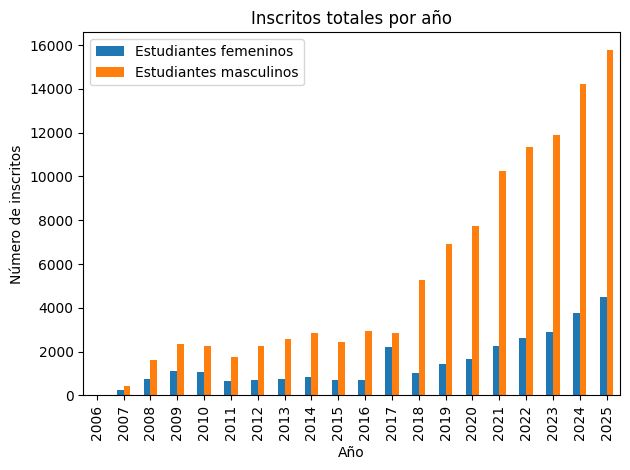

In [ ]:
inscritos_anio = (
    df
    .groupby("Año")[["Estudiantes femeninos","Estudiantes masculinos"]]
    .sum()
    .sort_index()
)

plt.figure()
inscritos_anio.plot(kind="bar")
plt.title("Inscritos totales por año")
plt.xlabel("Año")
plt.ylabel("Número de inscritos")
plt.tight_layout()
plt.show()

**Inscritos totales por año**

Se observa una tendencia general de crecimiento en la matrícula del ITLA desde 2006 hasta 2025. Los años con mayor inscripción son 2024-2025. Destaca un notable incremento a partir de 2017, posiblemente relacionado con la expansión de la oferta académica y el crecimiento del sector tecnológico en República Dominicana.

#### Inscritos por cuatrimestre

<Figure size 1000x600 with 0 Axes>

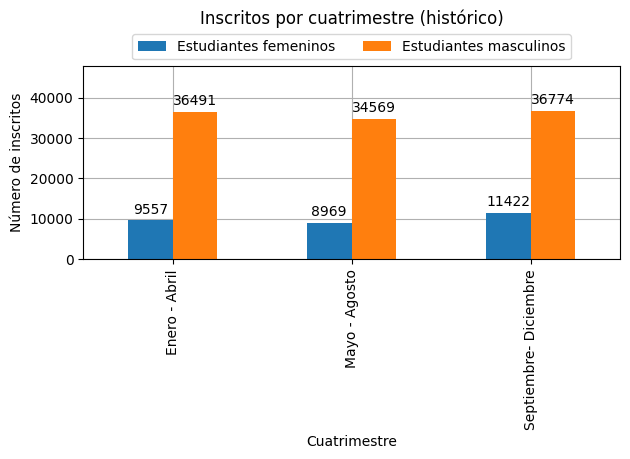

In [ ]:
inscritos_cuatrimestre = (
    df
    .groupby("Cuatrimestre")[["Estudiantes femeninos","Estudiantes masculinos"]]
    .sum()
    .sort_values(by="Cuatrimestre")
)

plt.figure(figsize=(10,6))
ax = inscritos_cuatrimestre.plot(kind="bar", zorder=2)

plt.title("Inscritos por cuatrimestre (histórico)", pad= 30)
plt.xlabel("Cuatrimestre")
plt.ylabel("Número de inscritos")
ax.grid(True, zorder=0)


for container in ax.containers:
    ax.bar_label(container, padding=3)

max_y = inscritos_cuatrimestre.values.max()
plt.ylim(0, max_y * 1.30)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.20), ncol=2)
plt.tight_layout()
plt.show()


**Inscritos por cuatrimestre** (histórico)

El cuatrimestre septiembre-diciembre es consistentemente el período de mayor inscripción, con más de 48,100 estudiantes históricos. Le sigue Enero-Abril y finalmente Mayo-Agosto. Este patrón sugiere que el inicio del año académico tradicional (septiembre) mantiene su relevancia como punto de entrada principal para nuevos estudiantes, un factor crítico para la planificación de recursos institucionales.

### Inscritos por Genero

In [ ]:
print("Total de inscritos por genero")
total_femenino = df['Estudiantes femeninos'].sum()
total_masculino = df['Estudiantes masculinos'].sum()
total_inscritos = total_femenino + total_masculino
print(f"Total inscritos Femenino: {total_femenino}")
print(f"Total inscritos Masculino: {total_masculino}")
print(f"Total inscritos: {total_inscritos}")
print(f"en porciento hay un {(total_femenino/total_inscritos):.2f}% de inscritos femeninos y un {(total_masculino/total_inscritos):.2f} de inscritos masculinos")
print("\n")

Total de inscritos por genero
Total inscritos Femenino: 29948
Total inscritos Masculino: 107834
Total inscritos: 137782
en porciento hay un 0.22% de inscritos femeninos y un 0.78 de inscritos masculinos




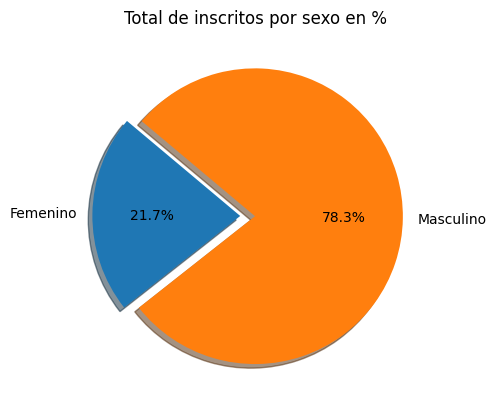

In [ ]:
labels = ['Femenino', 'Masculino']
sizes = [total_femenino, total_masculino]
explode = (0.1, 0)
plt.title("Total de inscritos por sexo en %")
plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%', shadow=True, startangle=140)
plt.show()

**Inscritos por sexo (histórico)**

Los inscritos masculinos representan el 78.3% del total, mientras que los inscritos femeninos representan el 21.7% restante.

### Informacion de las carreras

In [ ]:
print("Descripcion de las carreras")
display(df['Carrera'].describe())
print("\n")

print("Cada carrera con su totalidad de periodos de inscripcion desde 2006")
display(df['Carrera'].value_counts())
print("\n")

Descripcion de las carreras


,Carrera
count,475
unique,20
top,Tecnólogo en Desarrollo de Software
freq,58




Cada carrera con su totalidad de periodos de inscripcion desde 2006


,count
Carrera,
Tecnólogo en Desarrollo de Software,58
Tecnólogo en Manufactura Automatizada,58
Tecnólogo en Mecatrónica,55
Tecnólogo en Redes de Información,49
Tecnólogo en Multimedia,43
Tecnólogo en Sonido,28
Tecnólogo en Seguridad Informática,25
Tecnólogo en Diseño Industrial,20
Tecnólogo en Analítica y Ciencia de los Datos,17


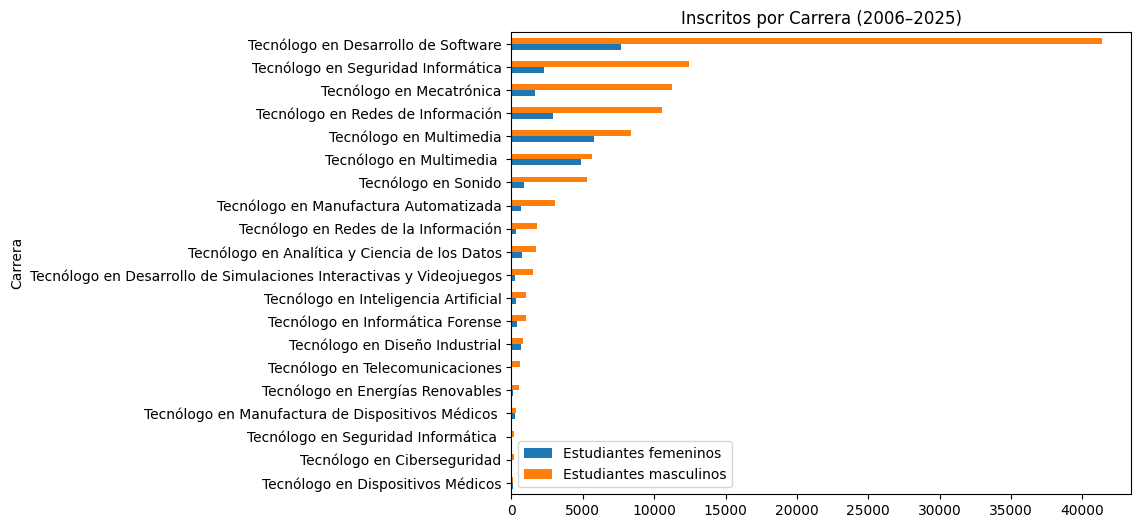

In [ ]:
# Inscritos por carrera
df.groupby("Carrera")[["Estudiantes femeninos","Estudiantes masculinos"]].sum().sort_values(by="Estudiantes masculinos").plot(kind="barh", figsize=(8,6))
plt.title("Inscritos por Carrera (2006–2025)")
plt.show()

**Inscritos por Carrera (2006–2025)**

"Tecnólogo en Desarrollo de Software" domina ampliamente con más de 10,000 inscripciones históricas, más del doble que la segunda carrera más popular. Otras carreras destacadas incluyen Redes y Telecomunicaciones, Multimedia y Diseño Gráfico. Este dato es crucial porque concentra un alto porcentaje de la matrícula en pocas carreras, lo que debe considerarse en la asignación de recursos (profesores, laboratorios, espacios físicos). Las carreras emergentes muestran inscripciones más bajas pero con potencial de crecimiento.

## Verificar calidad de los datos

In [ ]:
# Valores nulos
print(f"Valores nulos: {df.isnull().sum()}")
print("\n")

# filas duplicadas
print("Duplicados:", df.duplicated().sum())

# Eliminar duplicados si hay
dataset = df.drop_duplicates()

Valores nulos: Carrera                   0
Estudiantes femeninos     0
Estudiantes masculinos    0
Cuatrimestre              0
Año                       0
dtype: int64


Duplicados: 0


# **3- Preparación de los Datos**
---

## Correcion en error de nombre de carrera

In [ ]:
#corrigiendo error en de nombre de carrera
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
df['Carrera'] = df['Carrera'].replace({
    'Tecnólogo en Redes de Información': 'Tecnólogo en Redes de la Información',
    'Tecnólogo en Dispositivos Médicos' : 'Tecnólogo en Manufactura de Dispositivos Médicos'
})
df['Cuatrimestre'] = df['Cuatrimestre'].replace({
    "Septiembre- Diciembre" : "Septiembre - Diciembre",
})

# Datos corregidos
print("Carreras actuales corregidas")
print(f"Actualmente el ITLA cuenta con {df["Carrera"].nunique()} carreras las cuales son:\n")
for i in list(df[df['Año'] == 2025]['Carrera'].unique()):
  print(i)

print("Descripcion de las carreras")
display(df['Carrera'].describe())
print("\n")

print("Cada carrera con su totalidad de periodos de inscripcion desde 2006")
display(df['Carrera'].value_counts())
print("\n")

df.head()

Carreras actuales corregidas
Actualmente el ITLA cuenta con 16 carreras las cuales son:

Tecnólogo en Analítica y Ciencia de los Datos
Tecnólogo en Desarrollo de Simulaciones Interactivas y Videojuegos
Tecnólogo en Desarrollo de Software
Tecnólogo en Diseño Industrial
Tecnólogo en Energías Renovables
Tecnólogo en Informática Forense
Tecnólogo en Inteligencia Artificial
Tecnólogo en Manufactura Automatizada
Tecnólogo en Manufactura de Dispositivos Médicos
Tecnólogo en Mecatrónica
Tecnólogo en Multimedia
Tecnólogo en Redes de la Información
Tecnólogo en Seguridad Informática
Tecnólogo en Sonido
Tecnólogo en Telecomunicaciones
Tecnólogo en Ciberseguridad
Descripcion de las carreras


,Carrera
count,475
unique,16
top,Tecnólogo en Desarrollo de Software
freq,58




Cada carrera con su totalidad de periodos de inscripcion desde 2006


,count
Carrera,
Tecnólogo en Desarrollo de Software,58
Tecnólogo en Multimedia,58
Tecnólogo en Redes de la Información,58
Tecnólogo en Manufactura Automatizada,58
Tecnólogo en Mecatrónica,55
Tecnólogo en Seguridad Informática,28
Tecnólogo en Sonido,28
Tecnólogo en Diseño Industrial,20
Tecnólogo en Manufactura de Dispositivos Médicos,18


,Carrera,Estudiantes femeninos,Estudiantes masculinos,Cuatrimestre,Año
0,Tecnólogo en Desarrollo de Software,3,6,Septiembre - Diciembre,2006
1,Tecnólogo en Multimedia,8,9,Septiembre - Diciembre,2006
2,Tecnólogo en Redes de la Información,13,19,Septiembre - Diciembre,2006
3,Tecnólogo en Manufactura Automatizada,8,5,Septiembre - Diciembre,2006
4,Tecnólogo en Desarrollo de Software,8,13,Enero - Abril,2007


## Grafica de inscritos por carrera (Historico)

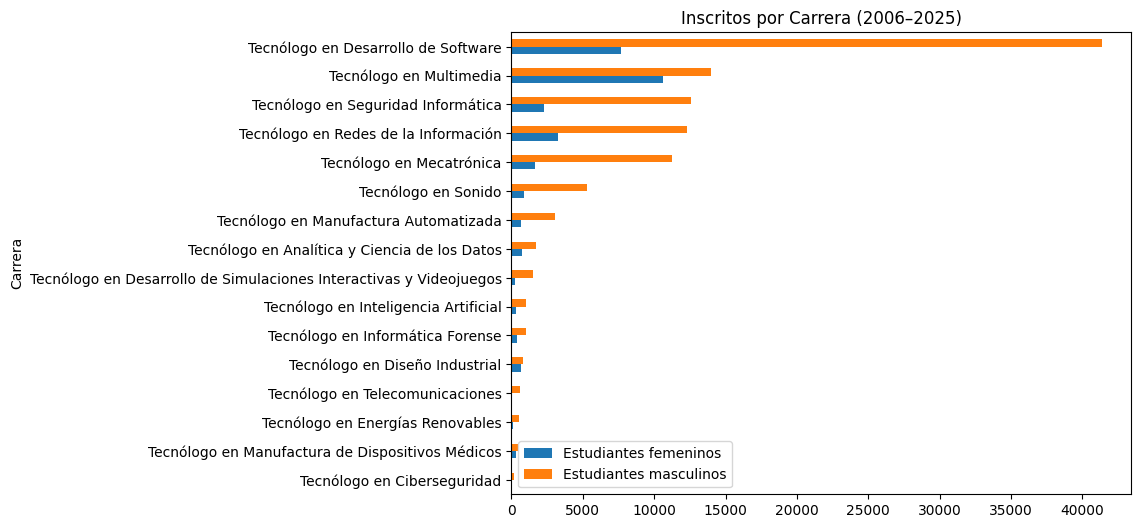

In [ ]:
# Inscritos por carrera
df.groupby("Carrera")[["Estudiantes femeninos","Estudiantes masculinos"]].sum().sort_values(by="Estudiantes masculinos").plot(kind="barh", figsize=(8,6))
plt.title("Inscritos por Carrera (2006–2025)")
plt.show()

## Modificacion del dataset

In [ ]:
# ahora modificamos el dataset para que esten separados los registros de estudiantes varones que de estudiantes mujeres
# lo modificamos de manera que el sexo sea una feature
dataset_transformado = pd.melt(
    df,
    id_vars=['Carrera', 'Cuatrimestre', 'Año'],
    value_vars=['Estudiantes femeninos', 'Estudiantes masculinos'],
    var_name='Columna Original',
    value_name='Estudiantes'
)
mapeo_sexo = {
    'Estudiantes femeninos': 'F',
    'Estudiantes masculinos': 'M'
}

dataset_transformado['Sexo'] = dataset_transformado['Columna Original'].map(mapeo_sexo)


# Eliminamos la columna que usamos para generar 'Sexo'
df_clean_sin_filtro = dataset_transformado.drop(columns=['Columna Original'])

# Reordenamos las columnas como solicitaste:
columnas_ordenadas = ['Carrera', 'Estudiantes', 'Sexo', 'Cuatrimestre', 'Año']
df_clean_sin_filtro = df_clean_sin_filtro[columnas_ordenadas]

print("Dataset transformado sin filtro")
display(df_clean_sin_filtro.sort_values(by=['Año','Carrera']).head())

Dataset transformado sin filtro


,Carrera,Estudiantes,Sexo,Cuatrimestre,Año
0,Tecnólogo en Desarrollo de Software,3,F,Septiembre - Diciembre,2006
475,Tecnólogo en Desarrollo de Software,6,M,Septiembre - Diciembre,2006
3,Tecnólogo en Manufactura Automatizada,8,F,Septiembre - Diciembre,2006
478,Tecnólogo en Manufactura Automatizada,5,M,Septiembre - Diciembre,2006
1,Tecnólogo en Multimedia,8,F,Septiembre - Diciembre,2006


In [ ]:
# Año actual - primer año en que aparece esa carrera
primer_anio_carrera = df_clean_sin_filtro.groupby('Carrera')['Año'].transform('min')
df_clean_sin_filtro['antiguedad de carrera'] = df_clean_sin_filtro['Año'] - primer_anio_carrera

# Crecimiento vs cuatrimestre anterior por carrera
orden_cuatrimestre = {
    'Enero - Abril': 1,
    'Mayo - Agosto': 2,
    'Septiembre - Diciembre': 3,
}

df_clean_sin_filtro['Cuatrimestre'] = df_clean_sin_filtro['Cuatrimestre'].map(orden_cuatrimestre)
df_clean_sin_filtro = df_clean_sin_filtro.sort_values(['Carrera', 'Año'])

# Lag del total de estudiantes por carrera
df_clean_sin_filtro['total_estudiantes_lag'] = df_clean_sin_filtro.groupby('Carrera')['Estudiantes'].shift(1)

# Crecimiento relativo
df_clean_sin_filtro['crecimiento sobre periodo anterior'] = (
    (df_clean_sin_filtro['Estudiantes'] - df_clean_sin_filtro['total_estudiantes_lag']) / df_clean_sin_filtro['total_estudiantes_lag']
)
df_clean_sin_filtro['crecimiento sobre periodo anterior'] = df_clean_sin_filtro['crecimiento sobre periodo anterior'].fillna(0)
df_clean_sin_filtro['crecimiento sobre periodo anterior'] = df_clean_sin_filtro['crecimiento sobre periodo anterior'].round(2)
df_clean_sin_filtro = df_clean_sin_filtro.drop(columns=['total_estudiantes_lag'])

df_clean_sin_filtro = df_clean_sin_filtro.sort_index()

print("Dataset final sin filtrado")
display(df_clean_sin_filtro)

df_clean = df_clean_sin_filtro[~((df_clean_sin_filtro["Año"] == 2025) & (df_clean_sin_filtro["Cuatrimestre"] == 3))]
df_clean_2025 = df_clean_sin_filtro[((df_clean_sin_filtro["Año"] == 2025) & (df_clean_sin_filtro["Cuatrimestre"] == 3))]
print("Dataset final filtrado sin septiembre - diciembre 2025")
display(df_clean)
print("Dataset final filtrado con septiembre - diciembre 2025")
display(df_clean_2025.head())

Dataset final sin filtrado


,Carrera,Estudiantes,Sexo,Cuatrimestre,Año,antiguedad de carrera,crecimiento sobre periodo anterior
0,Tecnólogo en Desarrollo de Software,3,F,3,2006,0,0.00
1,Tecnólogo en Multimedia,8,F,3,2006,0,0.00
2,Tecnólogo en Redes de la Información,13,F,3,2006,0,0.00
3,Tecnólogo en Manufactura Automatizada,8,F,3,2006,0,0.00
4,Tecnólogo en Desarrollo de Software,8,F,1,2007,1,0.33
...,...,...,...,...,...,...,...
945,Tecnólogo en Multimedia,476,M,3,2025,19,0.01
946,Tecnólogo en Redes de la Información,202,M,3,2025,19,-0.08
947,Tecnólogo en Seguridad Informática,1173,M,3,2025,9,0.00
948,Tecnólogo en Sonido,94,M,3,2025,9,-0.09


Dataset final filtrado sin septiembre - diciembre 2025


,Carrera,Estudiantes,Sexo,Cuatrimestre,Año,antiguedad de carrera,crecimiento sobre periodo anterior
0,Tecnólogo en Desarrollo de Software,3,F,3,2006,0,0.00
1,Tecnólogo en Multimedia,8,F,3,2006,0,0.00
2,Tecnólogo en Redes de la Información,13,F,3,2006,0,0.00
3,Tecnólogo en Manufactura Automatizada,8,F,3,2006,0,0.00
4,Tecnólogo en Desarrollo de Software,8,F,1,2007,1,0.33
...,...,...,...,...,...,...,...
929,Tecnólogo en Multimedia,473,M,2,2025,19,-0.02
930,Tecnólogo en Redes de la Información,219,M,2,2025,19,-0.05
931,Tecnólogo en Seguridad Informática,1169,M,2,2025,9,-0.01
932,Tecnólogo en Sonido,103,M,2,2025,9,0.13


Dataset final filtrado con septiembre - diciembre 2025


,Carrera,Estudiantes,Sexo,Cuatrimestre,Año,antiguedad de carrera,crecimiento sobre periodo anterior
459,Tecnólogo en Analítica y Ciencia de los Datos,101,F,3,2025,5,0.11
460,Tecnólogo en Desarrollo de Simulaciones Intera...,27,F,3,2025,4,0.04
461,Tecnólogo en Ciberseguridad,12,F,3,2025,0,0.20
462,Tecnólogo en Desarrollo de Software,355,F,3,2025,19,0.03
463,Tecnólogo en Diseño Industrial,55,F,3,2025,6,-0.13


### Creamos el dataset de X para Enero-Abril 2026

In [ ]:
# Definimos los parámetros para la predicción de Enero-Abril 2026
CARRERAS = df_clean_sin_filtro['Carrera'].unique()
SEXOS = df_clean_sin_filtro['Sexo'].unique()
ANIO_PRED = 2026

# Enero - Abril
CUATRIMESTRE_PRED = 1

# Creamos un dataframe con todas las combinaciones de Carrera y Sexo
df_pred_2026 = pd.DataFrame([
    (carrera, sexo, ANIO_PRED, CUATRIMESTRE_PRED)
    for carrera in CARRERAS
    for sexo in SEXOS
], columns=['Carrera', 'Sexo', 'Año', 'Cuatrimestre'])

# recalculamos antiguedad de carrera para 2026
primer_anio_carrera = df_clean_sin_filtro.groupby('Carrera')['Año'].min()
min_year_map = primer_anio_carrera.to_dict()

# Agregamos la antiguedad de carrera
df_pred_2026['antiguedad de carrera'] = df_pred_2026['Carrera'].map(min_year_map).apply(lambda x: ANIO_PRED - x)

# Calculamos crecimiento sobre periodo anterior

# Para la predicción, asumiremos el crecimiento del último periodo conocido (Sept-Dic 2025)

growth_q3_2025 = df_clean_sin_filtro[
    (df_clean_sin_filtro["Año"] == 2025) & (df_clean_sin_filtro["Cuatrimestre"] == 3)
].set_index(['Carrera', 'Sexo'])['crecimiento sobre periodo anterior']

# Asignamos esa tasa de crecimiento a Enero - Abril 2026
df_pred_2026 = df_pred_2026.set_index(['Carrera', 'Sexo'])
df_pred_2026['crecimiento sobre periodo anterior'] = growth_q3_2025
df_pred_2026 = df_pred_2026.reset_index()

# Rellenar posibles NaN con 0
df_pred_2026['crecimiento sobre periodo anterior'] = df_pred_2026['crecimiento sobre periodo anterior'].fillna(0)

print("Dataset de X para predicción para Enero-Abril 2026")
display(df_pred_2026)

Dataset de X para predicción para Enero-Abril 2026


,Carrera,Sexo,Año,Cuatrimestre,antiguedad de carrera,crecimiento sobre periodo anterior
0,Tecnólogo en Desarrollo de Software,F,2026,1,20,0.03
1,Tecnólogo en Desarrollo de Software,M,2026,1,20,-0.03
2,Tecnólogo en Multimedia,F,2026,1,20,0.00
3,Tecnólogo en Multimedia,M,2026,1,20,0.01
4,Tecnólogo en Redes de la Información,F,2026,1,20,-0.16
5,Tecnólogo en Redes de la Información,M,2026,1,20,-0.08
6,Tecnólogo en Manufactura Automatizada,F,2026,1,20,0.00
7,Tecnólogo en Manufactura Automatizada,M,2026,1,20,-0.24
8,Tecnólogo en Mecatrónica,F,2026,1,19,-0.13
9,Tecnólogo en Mecatrónica,M,2026,1,19,-0.08


# **4- Modelado**
---

## Division de datos

In [ ]:
df_clean.replace([np.inf, -np.inf], 0, inplace=True)

df_model = df_clean.copy()

# Convertimos variables categóricas (One-Hot Encoding)
df_model = pd.get_dummies(df_model, columns=['Carrera', 'Sexo'], drop_first=True)

# Definimos X e y
X = df_model.drop(columns=['Estudiantes'])
y = df_model['Estudiantes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos de entrenamiento: {X_train.shape}")
print(f"Datos de prueba: {X_test.shape}")

Datos de entrenamiento: (734, 20)
Datos de prueba: (184, 20)


## Entrenamientos

### Entrenamos Gradient Boosting

In [ ]:
print("Entrenando Gradient Boosting")
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

# Entrenar buscando los mejores parámetros
gb_grid.fit(X_train, y_train)

# Obtener el mejor modelo
gb_model = gb_grid.best_estimator_
y_pred_gb = gb_model.predict(X_test)

print(f"Mejor Gradient Boosting: {gb_grid.best_params_}")
print("Entrenamiento completado.")

Entrenando Gradient Boosting
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Mejor Gradient Boosting: {'learning_rate': 0.2, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
Entrenamiento completado.


### Entrenamos Random Forest


In [ ]:
print("Entrenando Random Forest de regresión")


rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 0.5],
    'bootstrap': [True, False]
}

# GridSearchCV para Random Forest
rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=rf_params,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=2,
    n_jobs=-1
)

# Entrenar buscando los mejores hiperparámetros
rf_grid.fit(X_train, y_train)

# Obtener el mejor modelo
rf_model = rf_grid.best_estimator_
y_pred_rf = rf_model.predict(X_test)

print(f"Mejor Árbol: {rf_grid.best_params_}")
print("Entrenamiento completado.")

Entrenando Random Forest de regresión
Fitting 3 folds for each of 144 candidates, totalling 432 fits
Mejor Árbol: {'bootstrap': False, 'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Entrenamiento completado.


# **5- Evaluación**
---

Evaluación Detallada en el Set de Prueba

Tabla Comparativa de Métricas:


,R2,MAE,RMSE
Modelo,,,
Gradient Boosting,0.951484,22.388253,54.457875
Random Forest,0.921831,26.503451,69.125087



El mejor modelo es: Gradient Boosting


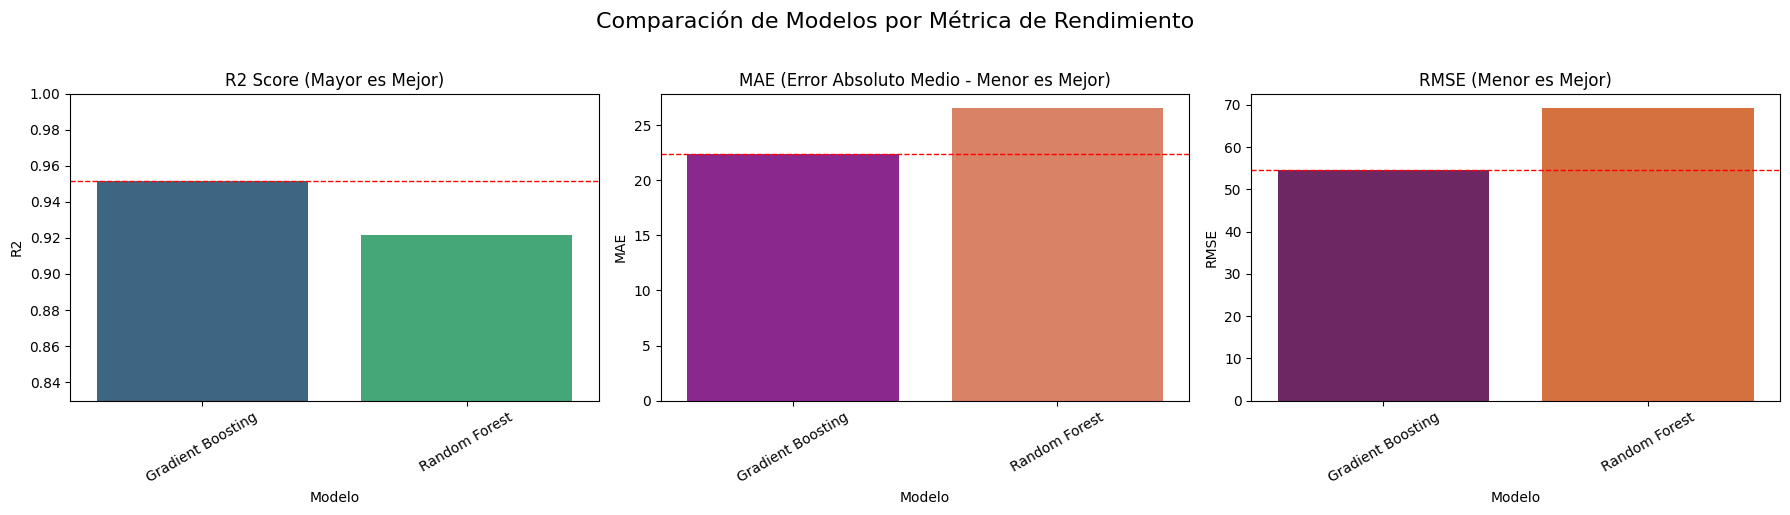

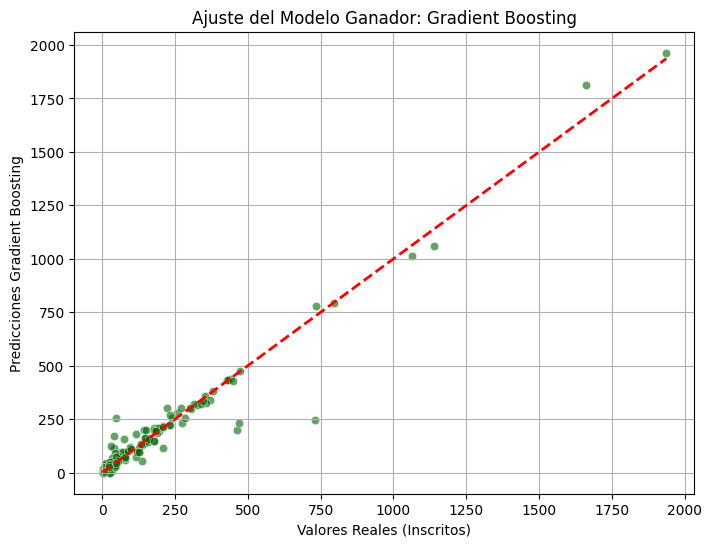

In [ ]:
modelos = {
    'Gradient Boosting': gb_model,
    'Random Forest': rf_model
}

resultados_evaluacion = []
modelo_ganador_objeto = None
mejor_r2 = -np.inf

print("Evaluación Detallada en el Set de Prueba")

for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    # Ajustar negativos a 0
    y_pred = [max(0, x) for x in y_pred]

    # Calcular métricas
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    resultados_evaluacion.append({
        'Modelo': nombre,
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse
    })

    # Eleccion del mejor modelo
    if r2 > mejor_r2:
        mejor_r2 = r2
        modelo_ganador_nombre = nombre
        modelo_ganador_objeto = modelo

df_res = pd.DataFrame(resultados_evaluacion)

# Tabla Comparativa
print("\nTabla Comparativa de Métricas:")
display(df_res.set_index('Modelo').sort_values(by='R2', ascending=False))
print(f"\nEl mejor modelo es: {modelo_ganador_nombre}")


# Gráficos Individuales de Métrica

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.suptitle('Comparación de Modelos por Métrica de Rendimiento', fontsize=16, y=1.02)

# Gráfico 1
sns.barplot(ax=axes[0], x='Modelo', y='R2', data=df_res, palette='viridis')
axes[0].set_title('R2 Score (Mayor es Mejor)')
axes[0].set_ylim(df_res['R2'].min() * 0.9, 1.0)
axes[0].tick_params(axis='x', rotation=30)
axes[0].axhline(mejor_r2, color='red', linestyle='--', linewidth=1)

# Gráfico 2
sns.barplot(ax=axes[1], x='Modelo', y='MAE', data=df_res, palette='plasma')
axes[1].set_title('MAE (Error Absoluto Medio - Menor es Mejor)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(df_res['MAE'].min(), color='red', linestyle='--', linewidth=1)

# Gráfico 3
sns.barplot(ax=axes[2], x='Modelo', y='RMSE', data=df_res, palette='inferno')
axes[2].set_title('RMSE (Menor es Mejor)')
axes[2].tick_params(axis='x', rotation=30)
axes[2].axhline(df_res['RMSE'].min(), color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

# Gráfico de Realidad vs Predicción

y_pred_ganador = modelo_ganador_objeto.predict(X_test)
y_pred_ganador = [max(0, x) for x in y_pred_ganador]

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_ganador, alpha=0.6, color='darkgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales (Inscritos)')
plt.ylabel(f'Predicciones {modelo_ganador_nombre}')
plt.title(f'Ajuste del Modelo Ganador: {modelo_ganador_nombre}')
plt.grid(True)
plt.show()

# **6- Despliegue**
---

## Probando el modelo con datos del septiembre-diciembre 2025

In [ ]:
X_2025_pred = df_clean_2025.copy()

# Convertimos variables categóricas (One-Hot Encoding)
X_2025_pred = pd.get_dummies(X_2025_pred, columns=['Carrera', 'Sexo'], drop_first=True)

# eliminamos la y
X_2025_pred = X_2025_pred.drop(columns=['Estudiantes'])

# Realizamos la predicción
y_pred_2025_gb = gb_model.predict(X_2025_pred)

# Agregamos las predicciones a los datos reales
df_clean_2025['Predichos Gradient Boosting'] = y_pred_2025_gb.round().astype(int)

# Post-procesamiento: Redondear y asegurar que no haya valores negativos
df_clean_2025['Predichos Gradient Boosting'] = [max(0, x) for x in y_pred_2025_gb.round().astype(int)]

# Calcular la diferencia
df_clean_2025['Diferencia Real vs Pred GB'] = df_clean_2025['Estudiantes'] - df_clean_2025['Predichos Gradient Boosting']

comparacion_2025 = df_clean_2025[[
    'Carrera',
    'Sexo',
    'Estudiantes',
    'Predichos Gradient Boosting',
    'Diferencia Real vs Pred GB',
]].sort_values(by='Carrera', ascending=True).reset_index(drop=True)

# Imprimir la tabla de comparación
print("Comparacion Datos Reales vs. Predicciones")
display(comparacion_2025.head(None))

Comparacion Datos Reales vs. Predicciones


,Carrera,Sexo,Estudiantes,Predichos Gradient Boosting,Diferencia Real vs Pred GB
0,Tecnólogo en Analítica y Ciencia de los Datos,F,101,98,3
1,Tecnólogo en Analítica y Ciencia de los Datos,M,204,191,13
2,Tecnólogo en Ciberseguridad,M,98,54,44
3,Tecnólogo en Ciberseguridad,F,12,26,-14
4,Tecnólogo en Desarrollo de Simulaciones Intera...,M,147,149,-2
5,Tecnólogo en Desarrollo de Simulaciones Intera...,F,27,55,-28
6,Tecnólogo en Desarrollo de Software,F,355,351,4
7,Tecnólogo en Desarrollo de Software,M,1931,1993,-62
8,Tecnólogo en Diseño Industrial,M,70,95,-25
9,Tecnólogo en Diseño Industrial,F,55,54,1


### Grafico

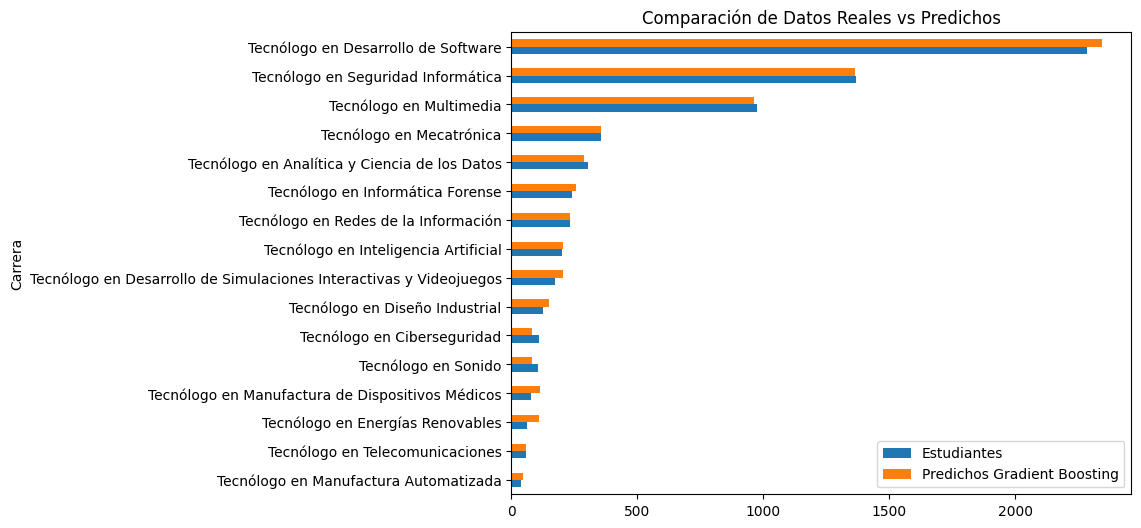

In [ ]:
comparacion_2025.groupby("Carrera")[["Estudiantes","Predichos Gradient Boosting"]].sum().sort_values(by="Estudiantes").plot(kind="barh", figsize=(8,6))
plt.title("Comparación de Datos Reales vs Predichos")
plt.show()

### Totales de Predicción

In [ ]:
total_reales = df_clean_2025['Estudiantes'].sum()
total_predichos_gb = df_clean_2025['Predichos Gradient Boosting'].sum()
diferencia_total_gb = df_clean_2025['Diferencia Real vs Pred GB'].sum()

print("Totales")
print(f"Total de estudiantes admitidos Reales: {total_reales}")
print(f"Total de estudiantes admitidos predichos por Gradient Boosting: {total_predichos_gb}")
print(f"Diferencia Total de predichos por Gradient Boosting e estudiantes admitidos Reales: {diferencia_total_gb}")
print(f"Porciento de Efectividad: {(100-((abs(diferencia_total_gb) / total_reales) * 100)):0.2f}%")
print("\n")

Totales
Total de estudiantes admitidos Reales: 6709
Total de estudiantes admitidos predichos por Gradient Boosting: 6854
Diferencia Total de predichos por Gradient Boosting e estudiantes admitidos Reales: -145
Porciento de Efectividad: 97.84%




### Grafico de totales

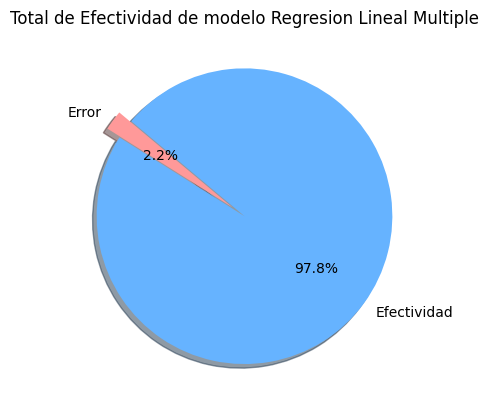

In [ ]:
# Grafica Porciento de Efectividad por modelo
labels = ['Error', 'Efectividad']
sizes = [(100 - (100-((abs(diferencia_total_gb) / total_reales) * 100))), (100-((abs(diferencia_total_gb) / total_reales) * 100))]
explode = (0.1, 0)
colors = ['#ff9999', '#66b3ff']
plt.title("Total de Efectividad de modelo Regresion Lineal Multiple")
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.show()

## Predicción para enero-abril 2026

In [ ]:
# preparamos el Dataframe para el modelo (One-Hot Encoding)
X_2026_pred = pd.get_dummies(df_pred_2026, columns=['Carrera', 'Sexo'], drop_first=True)

# Alineamos las columnas
missing_cols = set(X_train.columns) - set(X_2026_pred.columns)

for c in missing_cols:
    X_2026_pred[c] = 0

# Aseguraramos el orden
X_2026_pred = X_2026_pred[X_train.columns]

# Realizamos la predicción
y_pred_2026 = gb_model.predict(X_2026_pred)

# Post-procesamiento: Redondear y asegurar que no haya valores negativos
df_pred_2026['Estudiantes Predichos'] = [max(0, x) for x in y_pred_2026.round().astype(int)]

# resultados
predicciones_2026_final = df_pred_2026[[
    'Carrera',
    'Sexo',
    'Estudiantes Predichos',
    'Año',
    'Cuatrimestre',
]].sort_values(by=['Carrera', 'Sexo'], ascending=True).reset_index(drop=True)

print("Predicciones de Inscripción por Carrera y Género (Enero-Abril 2026)")
display(predicciones_2026_final.head(None))

Predicciones de Inscripción por Carrera y Género (Enero-Abril 2026)


,Carrera,Sexo,Estudiantes Predichos,Año,Cuatrimestre
0,Tecnólogo en Analítica y Ciencia de los Datos,F,78,2026,1
1,Tecnólogo en Analítica y Ciencia de los Datos,M,174,2026,1
2,Tecnólogo en Ciberseguridad,F,29,2026,1
3,Tecnólogo en Ciberseguridad,M,53,2026,1
4,Tecnólogo en Desarrollo de Simulaciones Intera...,F,63,2026,1
5,Tecnólogo en Desarrollo de Simulaciones Intera...,M,204,2026,1
6,Tecnólogo en Desarrollo de Software,F,364,2026,1
7,Tecnólogo en Desarrollo de Software,M,1989,2026,1
8,Tecnólogo en Diseño Industrial,F,64,2026,1
9,Tecnólogo en Diseño Industrial,M,85,2026,1


### Grafico

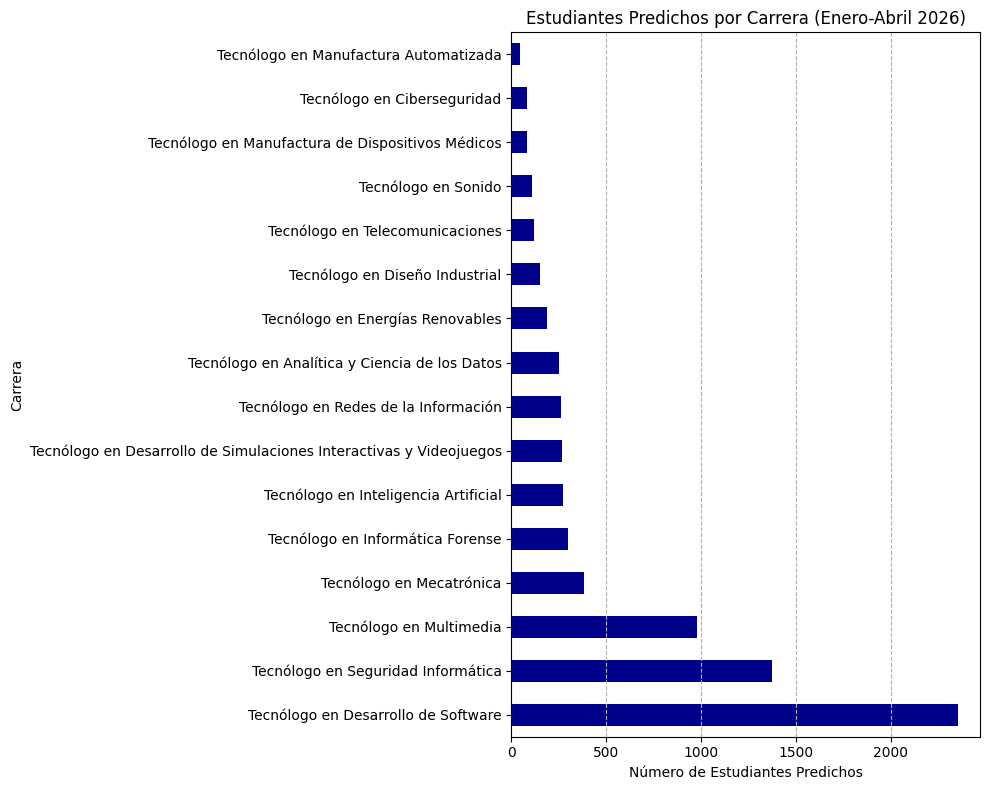

In [ ]:
# Graficamos las predicciones por carrera
pred_summary_2026 = predicciones_2026_final.groupby("Carrera")["Estudiantes Predichos"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
pred_summary_2026.plot(kind="barh", color='darkblue')
plt.title("Estudiantes Predichos por Carrera (Enero-Abril 2026)")
plt.xlabel("Número de Estudiantes Predichos")
plt.ylabel("Carrera")
plt.grid(axis='x', linestyle='--')
plt.tight_layout()
plt.show()

### Totales de Predicción

In [ ]:
# Mostrar totales de predicción
total_predichos_2026 = predicciones_2026_final['Estudiantes Predichos'].sum()

print("\nTotales de Predicción para Enero-Abril 2026")
print(f"Total de estudiantes predichos por Gradient Boosting (Enero-Abril 2026): {total_predichos_2026}")



Totales de Predicción para Enero-Abril 2026
Total de estudiantes predichos por Gradient Boosting (Enero-Abril 2026): 7213
